In [28]:
import os
print(os.getcwd())

/home/egork/Coding/hrt-datathon/yehor


In [29]:
import pandas as pd

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")

headlines_df = pd.read_parquet("../data/headlines_seen_train.parquet")
print(bars_df.columns)
print(bars_df.head())
print(headlines_df.columns)
print(headlines_df.head())

Index(['bar_ix', 'session', 'open', 'high', 'low', 'close'], dtype='object')
                 bar_ix  session  open    high     low   close
96537873709344        0        0   1.0  1.0029  0.9986  0.9999
96537874084912        0        1   1.0  1.0024  0.9980  1.0011
96537873709344        0        2   1.0  1.0005  0.9952  0.9957
96537874084912        0        3   1.0  1.0008  0.9986  1.0008
130065559268176       0        4   1.0  1.0031  0.9996  1.0009
Index(['session', 'headline', 'bar_ix'], dtype='object')
                 session                                           headline  \
130065551606432        0  Relvos Biosciences opens new office in Southea...   
96537875952912         0  Orevex Renewables secures $500M contract with ...   
96537871191376         0  Relvos Biosciences names new head of precision...   
96537875952912         0  Calvis Sciences secures $650M contract with a ...   
49156                  0  Yorvov Pharmaceuticals secures $180M contract ...   

             

In [30]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_session_with_news(
    bars_df,
    headlines_df,
    session_n,
    price_col="close",
    figsize=(14, 6),
    show_headlines=True,
    rotate_labels=90,
):
    """
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
    """

    # Filter data
    bars = bars_df[bars_df["session"] == session_n].copy()
    news = headlines_df[headlines_df["session"] == session_n].copy()

    if bars.empty:
        print(f"No bars found for session {session_n}")
        return

    # Sort bars
    bars = bars.sort_values("bar_ix")
    news = news.sort_values("bar_ix")

    fig, ax = plt.subplots(figsize=figsize)

    # Plot price line
    ax.plot(
        bars["bar_ix"],
        bars[price_col],
        lw=2,
        label=f"{price_col.title()} Price"
    )

    # Vertical lines for headlines
    for _, row in news.iterrows():
        x = row["bar_ix"]

        ax.axvline(
            x=x,
            linestyle="--",
            alpha=0.6,
            linewidth=1
        )

        if show_headlines:
            ax.text(
                x,
                bars[price_col].max(),
                row["headline"],
                rotation=rotate_labels,
                va="top",
                ha="right",
                fontsize=8,
                alpha=0.8
            )

    ax.set_title(f"Session {session_n}: Price Movement + Headlines")
    ax.set_xlabel("bar_ix")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

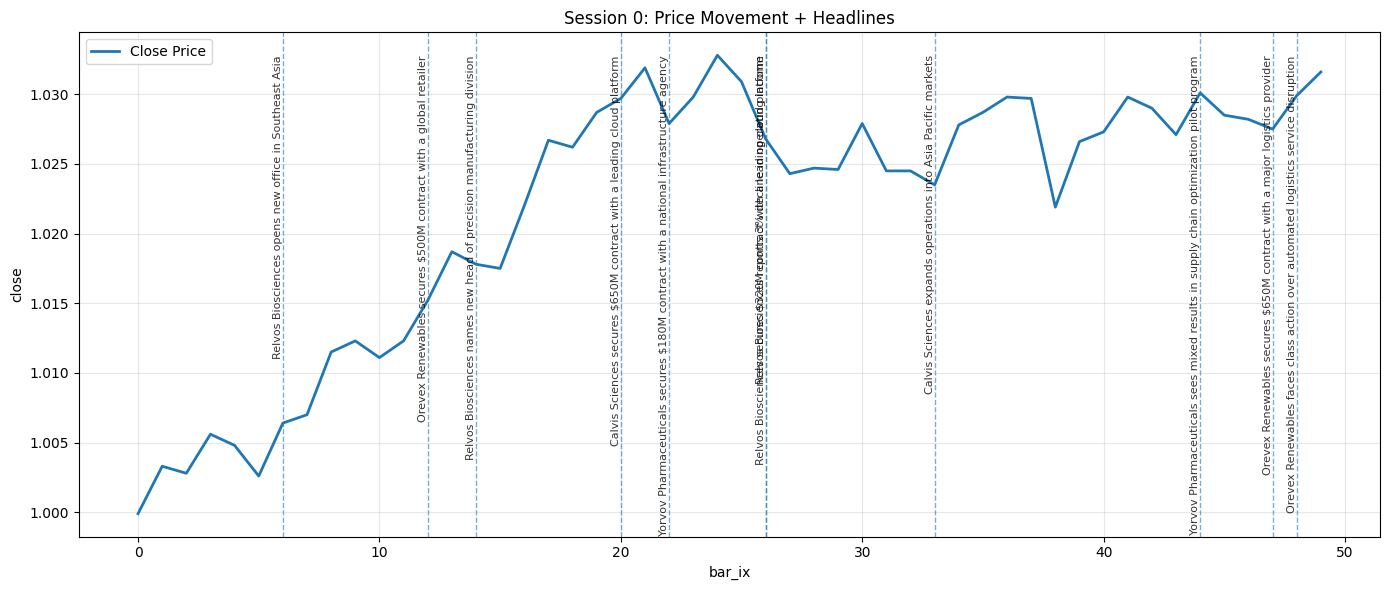

In [31]:
plot_session_with_news(bars_df, headlines_df, session_n=0)

In [ ]:
df = headlines_df.copy()
print(df.columns)

# If headlines are in a specific column, replace with actual name
headline_col = df[["headline"]]

# Extract headlines into a clean list of strings
headlines = (
    df[headline_col]
    .astype(str)
    .str.strip()
    .dropna()
    .tolist()
)

print(headlines)

Index(['session', 'headline', 'bar_ix'], dtype='object')


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices